# Gaming Toxicity Detection

**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward


In [19]:
# libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
import html as html_lib
from nltk.tokenize import TweetTokenizer


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import html as html_lib
from pathlib import Path
import os 
import spacy
nlp = spacy.load("en_core_web_sm")

# reproducibility
seed = 7524
np.random.seed(seed)

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))

# project root (notebooks/gaming/ -> notebooks/ -> project root)
PROJECT_ROOT = Path().resolve().parent.parent

In [20]:
# data directories
DATA_DIR_WOT  = PROJECT_ROOT / "data/processed_data/wot/"
DATA_DIR_DOTA = PROJECT_ROOT / "data/processed_data/dota/"

## World of Tanks

In [21]:
# read parquet file
wot = pd.read_parquet(DATA_DIR_WOT / "wot.parquet")
# check 
print(f"Dataset shape: {wot.shape}")
print(f"Dataset first 5 rows:\n{wot.head(5)}\n")
print(f"Dataset info:")
wot.info()


Dataset shape: (49386, 3)
Dataset first 5 rows:
   index                        message  label
0  30702                        no rush    0.0
1  18607  whatever ... watch the replay    0.0
2  32901                        useless    1.0
3  25964                      3 gunmark    0.0
4  28643                            lol    0.0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49386 entries, 0 to 49385
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    49386 non-null  int64  
 1   message  49386 non-null  object 
 2   label    49386 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


### Exploratory Data Analysis (EDA)

| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

#### Class distribution

In [4]:
# Class balance check
print(f"Class distribution:\n{wot['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{wot['label'].value_counts(normalize=True)}")

Class distribution:
label
0.0    38055
1.0     6248
2.0     4278
3.0      393
4.0      380
5.0       32
Name: count, dtype: int64

Class distribution (normalized):
label
0.0    0.770563
1.0    0.126514
2.0    0.086624
3.0    0.007958
4.0    0.007694
5.0    0.000648
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_41132\3772814331.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\nyuss\AppData\Local\Temp\ipykernel_41132\3772814331.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


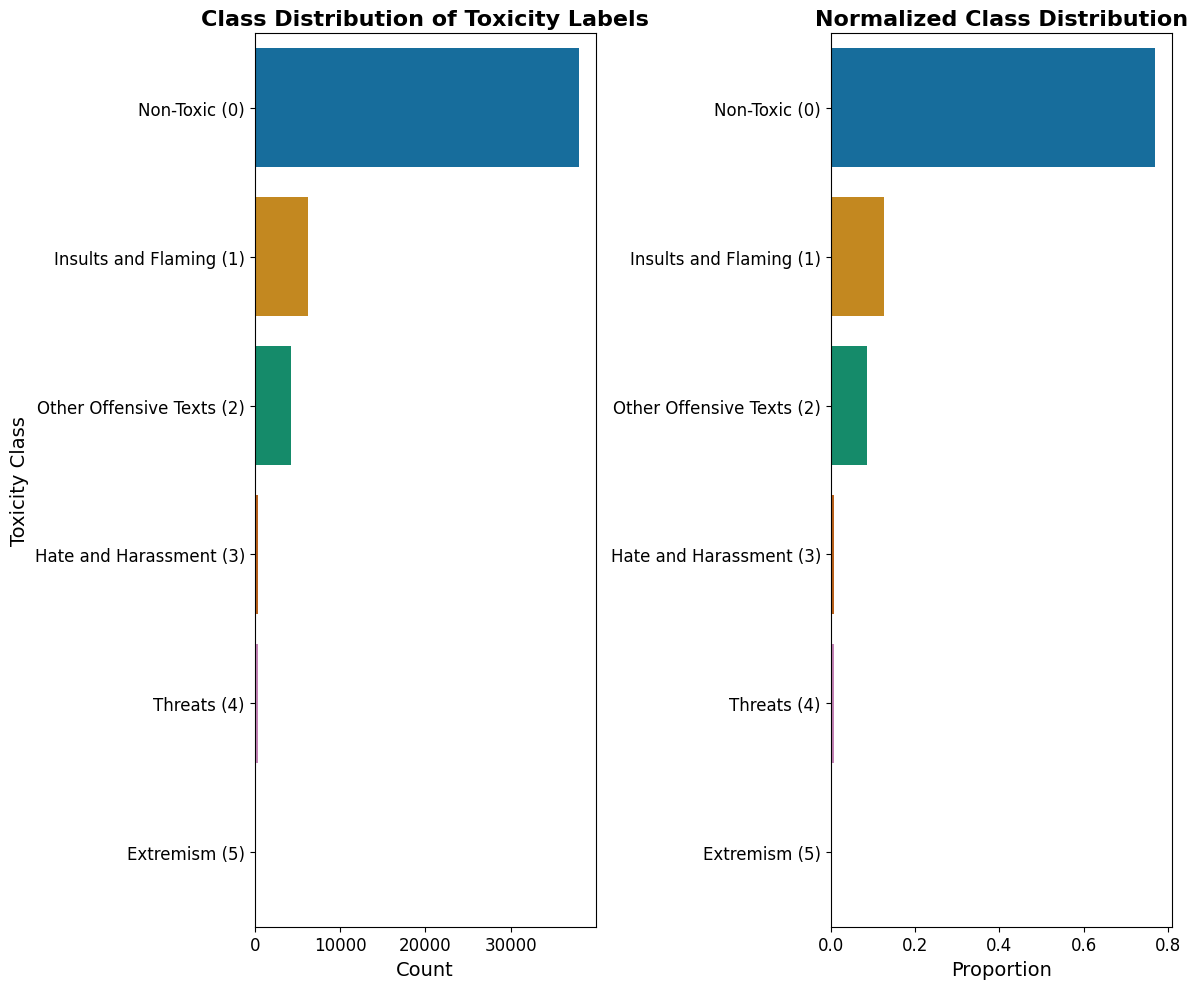

In [5]:
# Class balance plot + normalized class balance plot side by side

# class order and readable labels
class_order = [0, 1, 2, 3, 4, 5]
class_labels = [
    "Non-Toxic (0)",
    "Insults and Flaming (1)",
    "Other Offensive Texts (2)",
    "Hate and Harassment (3)",
    "Threats (4)",
    "Extremism (5)"
]

# map numeric labels to readable names
label_map = dict(zip(class_order, class_labels))
wot["label_name"] = wot["label"].map(label_map)

# normalized proportions
class_props = (
    wot["label"]
    .value_counts(normalize=True)
    .reindex(class_order)
)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# raw counts plot
sns.countplot(
    y="label_name",
    data=wot,
    order=class_labels,
    palette="colorblind",
    ax=axes[0]
)

# aesthetics
# title 
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=16)

# axis labels and ticks
axes[0].set_xlabel("Count", fontsize=14)
axes[0].set_ylabel("Toxicity Class", fontsize=14)

axes[0].tick_params(axis="y", labelsize=12)
axes[0].tick_params(axis="x", labelsize=12)


# normalized distribution
sns.barplot(
    x=class_props.values,
    y=class_labels,
    palette="colorblind",
    ax=axes[1]
)

# aesthetics 
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=16)

# axis labels and ticks 
axes[1].set_xlabel("Proportion", fontsize=14)

axes[1].tick_params(axis="y", labelsize=12)
axes[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

That gives us the idea that the class proportions are very imbalanced. We might experiment with binary vs multiclass classification later because of that. We could also merge minority labels to make it easier for model to learn data signals.

#### Non-English Messages (verification)

In [6]:
import re

NON_LATIN_SCRIPT = re.compile(
    r"[\u0400-\u04FF"   # Cyrillic
    r"\u4E00-\u9FFF"    # CJK unified ideographs
    r"\u3400-\u4DBF"    # CJK extension A
    r"\uF900-\uFAFF"    # CJK compatibility ideographs
    r"\u0600-\u06FF"    # Arabic
    r"\u0590-\u05FF"    # Hebrew
    r"\u3040-\u30FF"    # Japanese (Hiragana + Katakana)
    r"\uAC00-\uD7AF"    # Korean (Hangul syllables)
    r"\u1100-\u11FF"    # Korean (Hangul Jamo)
    r"\u0E00-\u0E7F"    # Thai
    r"\u0900-\u097F"    # Devanagari (Hindi)
    r"\u0980-\u09FF"    # Bengali
    r"\u0370-\u03FF"    # Greek
    r"\u10A0-\u10FF"    # Georgian
    r"\u0530-\u058F"    # Armenian
    r"\u1000-\u109F"    # Myanmar
    r"\u1780-\u17FF]"   # Khmer
)

non_english_count = wot["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(wot)) * 100:.2f}%")

Number of non-English script messages: 0
Percentage: 0.00%


In [7]:
# check 
wot[wot["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False)]

,index,message,label,label_name


We successfully deleted everything in cleaning phase. 

#### Number of words per document

In [8]:
# splitting the dataset 

# features and target
X = wot["message"]
y = wot["label"]

# First split: 10% for final testing, 90% remains for training/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.10, random_state=7524, shuffle = True, stratify= y)

# datasets 
# train
train_df = pd.DataFrame({
    "message": X_train,
    "label": y_train
}).reset_index(drop=True)

# validation 
validation_df = pd.DataFrame({
    "message": X_val,
    "label": y_val
}).reset_index(drop=True)

# check shapes 
print(f"Train dataset shape:{train_df.shape}\n")
print(f"Validation dataset shape:{validation_df.shape}\n")

Train dataset shape:(44447, 2)

Validation dataset shape:(4939, 2)



In [9]:
# summary statistics of comments
print("Summary statistics of comment lengths:")

# create new column with comment world lengths
train_df["comment_length"] = train_df["message"].str.split().str.len()

# summary statistics 
train_describe = train_df["comment_length"].describe()
train_describe 

Summary statistics of comment lengths:


count    44447.000000
mean         2.968074
std          2.489747
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         29.000000
Name: comment_length, dtype: float64

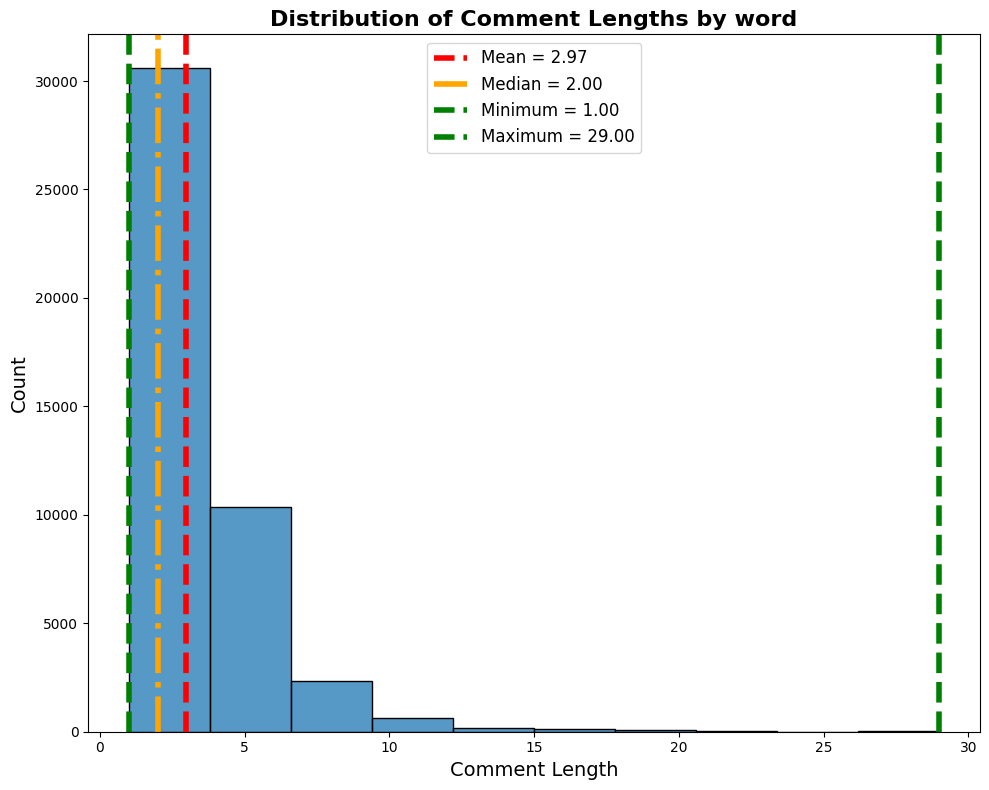

In [10]:
# distribution of world length 
# summary statistics
mean_len = train_df["comment_length"].mean()
median_len = train_df["comment_length"].median()
min_len = train_df["comment_length"].min()
max_len = train_df["comment_length"].max()

# plot
plt.figure(figsize=(10, 8))

# histogram plot
sns.histplot(
    train_df["comment_length"],
    bins=10,
    kde=False
)

# mean line
plt.axvline(
    mean_len,
    linestyle="--",
    linewidth=4,
    label=f"Mean = {mean_len:.2f}", 
    color = "red"
)

# median line
plt.axvline(
    median_len,
    linestyle="-.",
    linewidth=4,
    label=f"Median = {median_len:.2f}",
    color = "orange"
)

# min line 
plt.axvline(
    min_len,
    linestyle="--",
    linewidth=4,
    label=f"Minimum = {min_len:.2f}",
    color = "green"
)

# max line 
plt.axvline(
    max_len,
    linestyle="--",
    linewidth=4,
    label=f"Maximum = {max_len:.2f}",
    color = "green"
)

# title and labels
plt.title("Distribution of Comment Lengths by word", fontweight="bold", fontsize=16)

# xlabel
plt.xlabel("Comment Length", fontsize=14)

# ylabel
plt.ylabel("Count", fontsize=14)

# legend
plt.legend(fontsize=12)

# show the plot 
plt.tight_layout()
plt.show()

Messages are extremely short - median 2 words, max 29 in train data. Over 60% of messages are 1-3 words, confirming that gaming chat is reaction-driven rather than conversational. This justifies unigram + bigram TF-IDF: trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [11]:
# check messages 
# comments longer than or equal to the median top 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,get 7 kill,3,0.0
1,its one against 4,4,0.0
2,HAVE NICE BAN :)XD,4,2.0
5,always lopsided stats,3,0.0
6,iam low ammo,3,0.0
7,"yes heavy s, you are best",6,0.0
8,noob MT,2,1.0
9,Im Spotted at G2!,4,0.0
10,congrats on the medal,4,0.0
11,bASE !!!,2,0.0


In [12]:
# comments longer than or equal to the median bottom 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
44435,"marcix06 (P.44 Pantera), you are blocking my t...",8,0.0
44436,\goood light,2,0.0
44437,oh wow,2,0.0
44439,-5k or what,3,0.0
44440,BCIE NCIE NCIE :!!!,4,0.0
44441,ebr spot,2,0.0
44442,push a bit,3,0.0
44443,unistall game,2,1.0
44444,you are subnormal,3,1.0
44446,7.5k not too bad,4,0.0


This confirms that if we use `trigrams`, the model potentially might overfit to longer sentences without actually capturing the context.

In [13]:
# comments shoterter than the median top 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
3,8k,1,0.0
4,sure,1,0.0
13,gg,1,0.0
32,lol,1,0.0
33,ATY,1,0.0
36,time,1,0.0
37,gg,1,0.0
44,empty,1,0.0
45,gg,1,0.0
46,awwww.,1,0.0


In [14]:
# comments shorter than the median bottom 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
44417,gj,1,0.0
44419,gg,1,0.0
44420,tea,1,0.0
44423,gj,1,0.0
44424,ok,1,0.0
44425,time,1,0.0
44427,gg,1,0.0
44434,gl,1,0.0
44438,gg,1,0.0
44445,bravo,1,0.0


#### Word Frequency analysis

In [15]:
# combine all messages
all_text = " ".join(X_train.astype(str))

# tokenize
words = all_text.split()

# frequency table
word_freq = pd.DataFrame(Counter(words).items(), 
                         columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)

# top 20
word_freq.head(20)

,word,count
39,gg,3353
29,at,2165
22,you,2072
28,Spotted,1822
27,Im,1806
33,the,1675
132,i,1493
37,go,1478
279,to,1279
108,is,1170


A lot of stop words, we might need to drop them later in pre-processing, since they do not reveal any contextual information. However we might need to think how to deal with stopwords which are part of the phrase, for example: `You` versus `Fuck you`.

In [16]:
# stopwords dictionary 
EXTRA = {
    # informal contractions sklearn misses
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve",

    # pure filler with no class signal
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "rng",
    "play", "game", "tank", "spot",
    "today", "people", "kids", "nice", "sry", 

    # more fillers
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
     "elc", "ebr", "wg", "wot", "tier", "doing", "loose",

}   

# append with sklearn dictionary
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA)  # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'cannot', 'rather', 'inc', 'whereafter', 'ours', 'how', 'again', 'the', 'whereby', 'three', 'when', 'another', 'found', 'come', 'around', 'guys', 'has', 'whence', 'everything', 'ourselves', 'sometime', 'becoming', 'less', 'although', 'otherwise', 'eleven', 'whither', 'find', 'before', 'due', 'get', 'me', 'ah', 'xd', 'ebr', 'not', 'sincere', 'often', 'game', 'upon', 'yep', 'hers', 'nor', 'together', 'whose', 'ie', 'because', 'made', 'ur', 'thx', 'hereafter', 'wouldnt', 'nope', 'other', 'it', 'put', 'a', 'hereby', 'who', 'within', 'thence', 'wasnt', 'keep', 'doing', 'alone', 'his', 'them', 'however', 'once', 'im', 'hasnt', 'um', 'were', 'rng', 'nowhere', 'people', 'youre', 'nobody', 'against', 'lol', 'forty', 'co', 'except', 'few', 'yourselves', 'like', 'in', 'now', 'one', 'mostly', 'as', 'she', 'wherever', 'while', 'or', 'cant', 'must', 'be', 'hence', 'thin', 'fifty', 'whether', 'at', 'seems', 'these', 'could', 'there', 'therefore', 'time', 'then', 'ten', 'describe', 'here', 

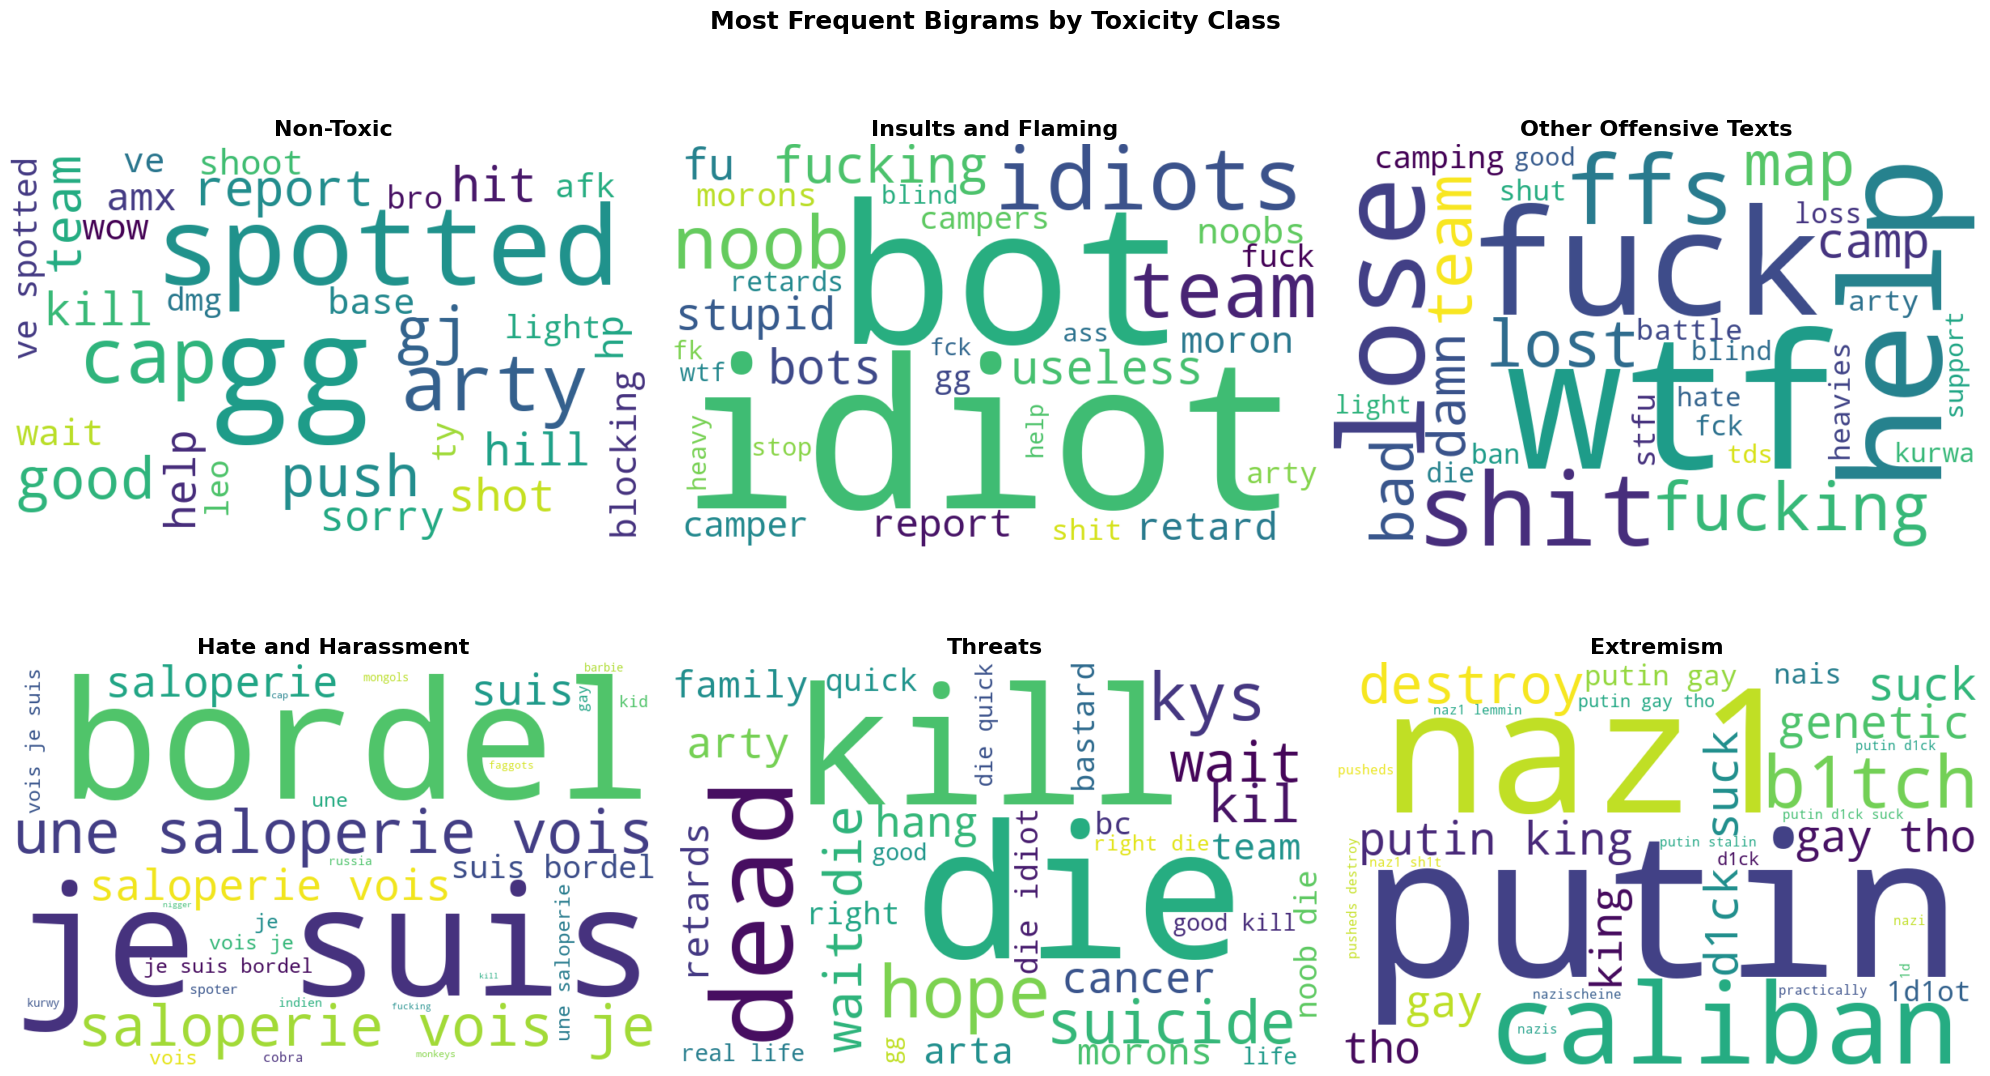

In [17]:
# class map
class_map = {
    0: "Non-Toxic",
    1: "Insults and Flaming",
    2: "Other Offensive Texts",
    3: "Hate and Harassment",
    4: "Threats",
    5: "Extremism"
}



# figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# create world clouds 
for i, cls in enumerate(sorted(train_df["label"].unique())):
    class_text = train_df.loc[train_df["label"] == cls, "message"].astype(str)
    
    # bigram vectorizer 
    bigram_vectorizer = CountVectorizer(
        # normalize accents
        strip_accents = "unicode", 
        # lowercase
        lowercase = True, 
        # stop words
        stop_words = list(STOPWORDS),
        max_df = 0.90,
        # ngram range
        ngram_range= (1, 3))
    
    
    # bigrams
    bigrams_trian = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_trian.sum(axis=0).A1
    bigram_names = bigram_vectorizer.get_feature_names_out()
    
    # bigrams frequency 
    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count": bigram_counts
    }).sort_values(by="count", ascending=False).head(30)
    

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], 
                                bigram_freq_train["count"]))
        
        # worcloud 
        wordcloud = WordCloud(
            width=800,
            height=500,
            background_color="white"
        ).generate_from_frequencies(bigram_dict)
        
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)

# design
plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Non-Toxic is coordination language, Insults attack skill, Hate attacks identity, Threats wish harm, Extremism uses leetspeak evasion.

### Pre-processing

| Feature | TweetTokenizer | Standard (split / CountVectorizer default) |
|---|---|---|
| Handles `@mentions`, `#hashtags` | Keeps as single token | Splits on `#`, `@` |
| Repeated chars (`looool`, `!!!!!!`) | Collapses to max 3 (`loool`, `!!!`) | Keeps full noise |
| Emoticons (`:)`, `:(`) | Preserved as tokens | Broken or dropped |
| Gaming shorthand (`gg`, `wtf`, `xD`) | Preserved as-is | Usually fine but no special handling |
| All-caps preservation | Configurable (`preserve_case`) | Not supported |
| Punctuation inside words | Handles intelligently | Often splits incorrectly |
| Informal language | Designed for it | Designed for formal text |

**Bottom line:** Gaming chat is structurally identical to Twitter - short, informal, abbreviation-heavy, emoticon-rich. TweetTokenizer was built for exactly this domain.


In [22]:
# apply 
from src.tokenizer import tokenize

train_df["clean_tokens"] = train_df["message"].apply(tokenize)
validation_df["clean_tokens"] = validation_df["message"].apply(tokenize)

# check 
train_df["clean_tokens"].head(100)

0                                     [7, kill]
1                                           [4]
2     [HAVE_CAPS, NICE_CAPS, BAN_CAPS, XD_CAPS]
3                                          [8k]
4                                        [sure]
                        ...                    
95                                  [SPOT_CAPS]
96     [russian, tanks, having, cloaking, camo]
97                      [shitters, failed, cap]
98                                   [YES_CAPS]
99                                     [losing]
Name: clean_tokens, Length: 100, dtype: object

All-caps words (`WTF`, `GG`, `NOOB`) carry expressive intensity in gaming - lowercasing them would lose that signal. Collapsing repeated punctuation reduces noise without removing the punctuation type itself.

#### Save Splits

In [23]:
# save splits to parquet 
train_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_train_ml.parquet", index=False)
validation_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_val_ml.parquet", index=False)


print("Saved:")
print(f"wot_train_ml.parquet - {train_df.shape}")
print(f"wot_val_ml.parquet - {validation_df.shape}")

Saved:
wot_train_ml.parquet - (44447, 4)
wot_val_ml.parquet - (4939, 3)


Three parquet files saved - one per split. 

## Dota 2 (CONDA)

In [24]:
# load Dota parquet
dota = pd.read_parquet(DATA_DIR_DOTA / "dota.parquet")
print(f"Dataset shape: {dota.shape}")
print(f"\nFirst 5 rows:\n{dota.head(5)}\n")
print(dota.info())

Dataset shape: (35813, 4)

First 5 rows:
   index  message  label  split
0  11263     wow!      0  train
1  13741      WTF      0  train
2  22125  wpe wpe      0  train
3   6453   hahaha      0  train
4   9644      wtf      0  train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35813 entries, 0 to 35812
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    35813 non-null  int64 
 1   message  35813 non-null  object
 2   label    35813 non-null  int64 
 3   split    35813 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.1+ MB
None


### Exploratory Data Analysis (EDA)

| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

#### Class distribution

In [25]:
print(f"Class distribution:\n{dota['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{dota['label'].value_counts(normalize=True)}")

Class distribution:
label
0    25784
1     4778
2     2708
3     2543
Name: count, dtype: int64

Class distribution (normalized):
label
0    0.719962
1    0.133415
2    0.075615
3    0.071008
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_41132\937577134.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
C:\Users\nyuss\AppData\Local\Temp\ipykernel_41132\937577134.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])


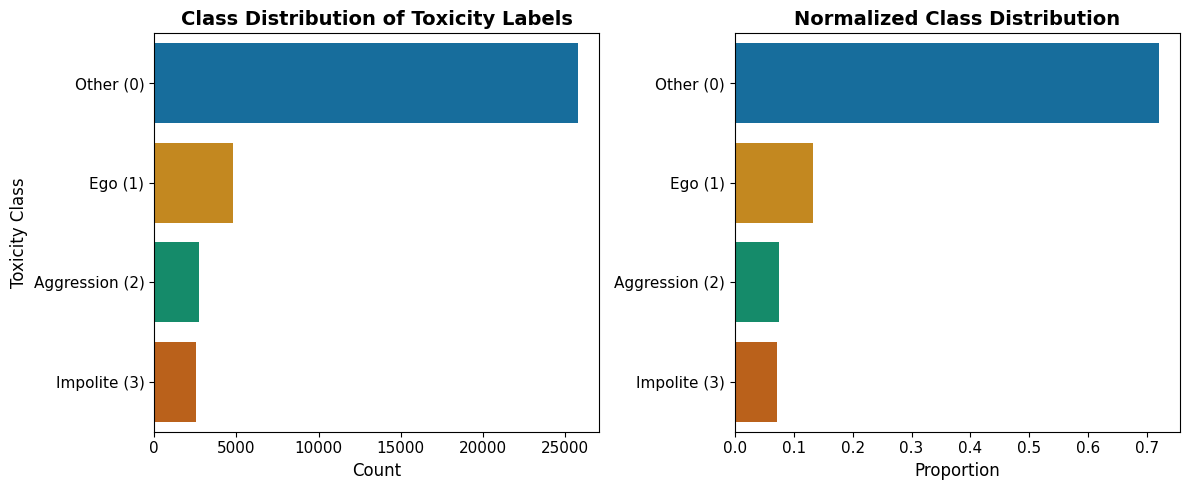

In [26]:
# distribution plot 
class_order_dota  = [0, 1, 2, 3]
class_labels_dota = ["Other (0)", "Ego (1)", "Aggression (2)", "Impolite (3)"]
label_map_dota    = dict(zip(class_order_dota, class_labels_dota))

dota["label_name"] = dota["label"].map(label_map_dota)

class_props = dota["label"].value_counts(normalize=True).reindex(class_order_dota)

# figure size 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot
sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Count", fontsize=12)
axes[0].set_ylabel("Toxicity Class", fontsize=12)
axes[0].tick_params(labelsize=11)

# second plot
sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Proportion", fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

The distribution of classes in dota dataset is less imbalanced, but there is still imbalance. We again need to think about potential merging of classes, changing goal to binary classification or testing against multi-classification.

#### Non-English Messages (verification)

Dota 2 is a globally played game - non-ASCII messages are common. We drop them since we are building an English-only classifier.

In [27]:
# count non-ASCII messages
non_english_count = dota["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(dota)) * 100:.2f}%")


Number of non-English script messages: 0
Percentage: 0.00%


Everything's clean.

#### Word Frequency Analysis

In [28]:
# train/val split — stratified to preserve class proportions
X_dota = dota["message"]
y_dota = dota["label"]

X_dota_train, X_dota_val, y_dota_train, y_dota_val = train_test_split(
    X_dota, y_dota, test_size=0.10, random_state=seed, shuffle=True, stratify=y_dota
)

dota_train_df = pd.DataFrame({"message": X_dota_train, "label": y_dota_train}).reset_index(drop=True)
dota_val_df   = pd.DataFrame({"message": X_dota_val,   "label": y_dota_val}).reset_index(drop=True)

print(f"Train dataset shape: {dota_train_df.shape}")
print(f"Validation dataset shape: {dota_val_df.shape}")

Train dataset shape: (32231, 2)
Validation dataset shape: (3582, 2)


#### Number of words per document

In [29]:
# summary statistics of comment lengths
print("Summary statistics of comment lengths:")
dota_train_df["comment_length"] = dota_train_df["message"].str.split().str.len()
dota_train_df["comment_length"].describe()

Summary statistics of comment lengths:


count    32231.000000
mean         3.342714
std          3.227530
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         51.000000
Name: comment_length, dtype: float64

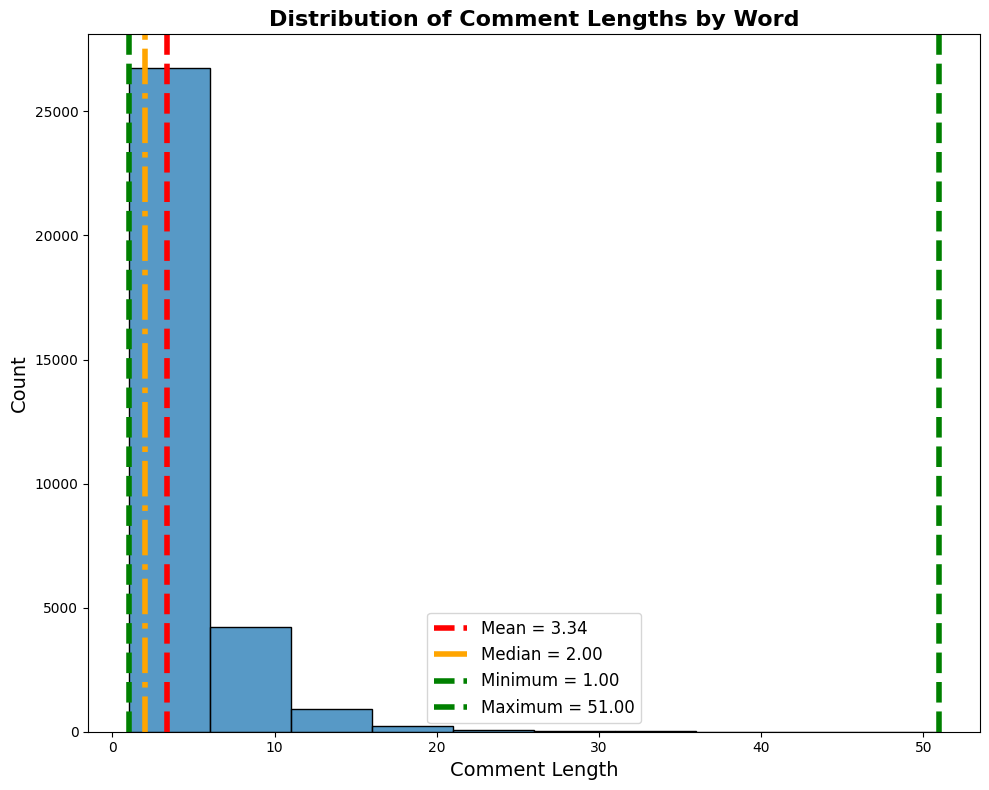

In [30]:
# distribution of comment lengths by word
mean_len   = dota_train_df["comment_length"].mean()
median_len = dota_train_df["comment_length"].median()
min_len    = dota_train_df["comment_length"].min()
max_len    = dota_train_df["comment_length"].max()

plt.figure(figsize=(10, 8))
sns.histplot(dota_train_df["comment_length"], bins=10, kde=False)

plt.axvline(mean_len,   linestyle="--", linewidth=4, label=f"Mean = {mean_len:.2f}",    color="red")
plt.axvline(median_len, linestyle="-.", linewidth=4, label=f"Median = {median_len:.2f}", color="orange")
plt.axvline(min_len,    linestyle="--", linewidth=4, label=f"Minimum = {min_len:.2f}",  color="green")
plt.axvline(max_len,    linestyle="--", linewidth=4, label=f"Maximum = {max_len:.2f}",  color="green")

plt.title("Distribution of Comment Lengths by Word", fontweight="bold", fontsize=16)
plt.xlabel("Comment Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Again, we can see than mean and median number of words in each message is ~2. We will utilize unigrams/bigrams for dota dataset as well.

In [31]:
# comments longer than or equal to the median top 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,with no dick?,3,1
2,pause please ibrb,3,2
5,thats why i am going for the yolo plays,9,0
6,get team stupid seee comeback is real,7,1
9,ez mid tiny,3,3
10,yuki is that a girl's name,6,0
11,rolf of the week you fucking bashed with your ...,18,1
14,you can thanks tusk for throwing,6,0
15,i'm on my way ;),5,0
16,Wp Useless tard,3,1


In [32]:
# comments longer than or equal to the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
32210,the fuck ruptured? ok,4,1
32212,we took down 3 when we're all present,8,0
32213,what a boring game jesus,5,0
32214,genuinely no idea,3,0
32215,who knows,2,0
32217,that is just sodium,4,0
32218,WHAT KIND OF JOKE IS THAT?,6,0
32221,ecks dee,2,0
32227,cant escape this ceasepool,4,0
32229,gg wp,2,0


In [33]:
# comments shorter than the median top 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
1,hf,1,0
3,recorder?,1,0
4,?,1,0
7,lol,1,0
8,goteem,1,0
12,g,1,2
13,OK?,1,0
17,GGWP,1,0
18,gg,1,0
19,Wew,1,0


In [34]:
# comments shorter than the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
32216,ggwp,1,0
32219,b?,1,0
32220,Piece,1,0
32222,bam,1,0
32223,w8,1,2
32224,lol,1,0
32225,LOL,1,0
32226,g,1,2
32228,+,1,0
32230,ez,1,3


Messages are extremely short - median 2 words, max ~51 in train data. Dota 2 chat mirrors WoT: reaction-driven, not conversational. This confirms unigram + bigram TF-IDF is the right choice - trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [35]:
# top 20 most frequent words in training set
all_text = " ".join(X_dota_train.astype(str))
words = all_text.split()

word_freq = pd.DataFrame(Counter(words).items(), columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)
word_freq.head(20)

,word,count
64,gg,2381
11,i,1434
217,u,1382
38,you,1258
25,lol,1235
27,ez,1094
8,?,904
23,is,892
32,a,843
106,me,829


In [36]:
# stopwords dictionary 
EXTRA = {
    # contractions
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve", "did",

    # pure filler
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",
    "xd", "lol", "omg", "thx", "sry", "hf",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "rng",
    "play", "game", "tank", "spot",
    "today", "people", "kids", "nice", "sry", 

    # more fillers
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
     "elc", "ebr", "wg", "wot", "tier", "doing", "loose",

    # Dota hero names only
    "abaddon", "alchemist", "axe", "bane", "batrider", "beastmaster",
    "bloodseeker", "brewmaster", "bristleback", "broodmother", "centaur",
    "chen", "clinkz", "clockwerk", "dazzle", "dawnbreaker", "disruptor",
    "doom", "enchantress", "enigma", "grimstroke", "gyrocopter", "hoodwink",
    "huskar", "invoker", "io", "jakiro", "juggernaut", "kunkka", "leshrac",
    "lich", "lifestealer", "lina", "lion", "luna", "lycan", "magnus",
    "marci", "mars", "medusa", "meepo", "mirana", "morphling", "muerta",
    "necrophos", "oracle", "pangolier", "phoenix", "puck", "pudge", "pugna",
    "razor", "riki", "rubick", "silencer", "slark", "slardar", "snapfire",
    "sniper", "spectre", "sven", "techies", "tidehunter", "timbersaw",
    "tinker", "tiny", "tusk", "underlord", "undying", "ursa", "viper",
    "visage", "warlock", "weaver", "zeus", "kez", "largo",

    # hero abbreviations
    "sf", "qop", "ta", "am", "es", "pa", "pl", "wk", "dk",
    "lc", "tb", "sk", "ns", "od", "wd", "sd", "ss", "kotl",
    "mk", "vs", "dp", "ck", "bh", "sb", "ember", "void", "storm",
    "jugg", "jug", "drow", "bara", "gyro", "legion", "rosh", "clock",
    "necro", "invo", "potm",

    # game mechanics with zero signal
    "ggwp", "mmr", "ff", "dc", "w8", "rc",
    "reconnecting", "reconnect", "lag",
    "just", "like", "really", "guys", "know", "come",
    "want", "time", "got", "win", "play", "game",
    "end", "nice", "good", "wait", "pro", "wow",
    "haha", "rofl", "ty", "thanks", "said", "min",
    "sec", "wr", "need", "team", "afk", }

# append with sklearn dictionary
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA)  # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'cannot', 'rather', 'inc', 'doom', 'whereafter', 'ours', 'how', 'tidehunter', 'huskar', 'leshrac', 'again', 'the', 'want', 'whereby', 'three', 'bloodseeker', 'when', 'another', 'found', 'come', 'around', 'guys', 'has', 'magnus', 'bristleback', 'gyro', 'zeus', 'spectre', 'invo', 'whence', 'good', 'disruptor', 'min', 'everything', 'ourselves', 'sometime', 'becoming', 'legion', 'less', 'although', 'otherwise', 'eleven', 'whither', 'find', 'before', 'due', 'get', 'me', 'lina', 'ah', 'wk', 'xd', 'ebr', 'not', 'sincere', 'often', 'game', 'upon', 'yep', 'hers', 'nor', 'did', 'together', 'whose', 'axe', 'ie', 'because', 'rubick', 'made', 'ur', 'thx', 'hereafter', 'wouldnt', 'nope', 'other', 'it', 'put', 'a', 'hereby', 'who', 'within', 'thence', 'wasnt', 'keep', 'sb', 'doing', 'alone', 'his', 'them', 'however', 'team', 'once', 'im', 'hasnt', 'um', 'were', 'rng', 'nowhere', 'people', 'ggwp', 'youre', 'nobody', 'against', 'pa', 'lol', 'batrider', 'wow', 'timbersaw', 'forty', 'co', 'exc

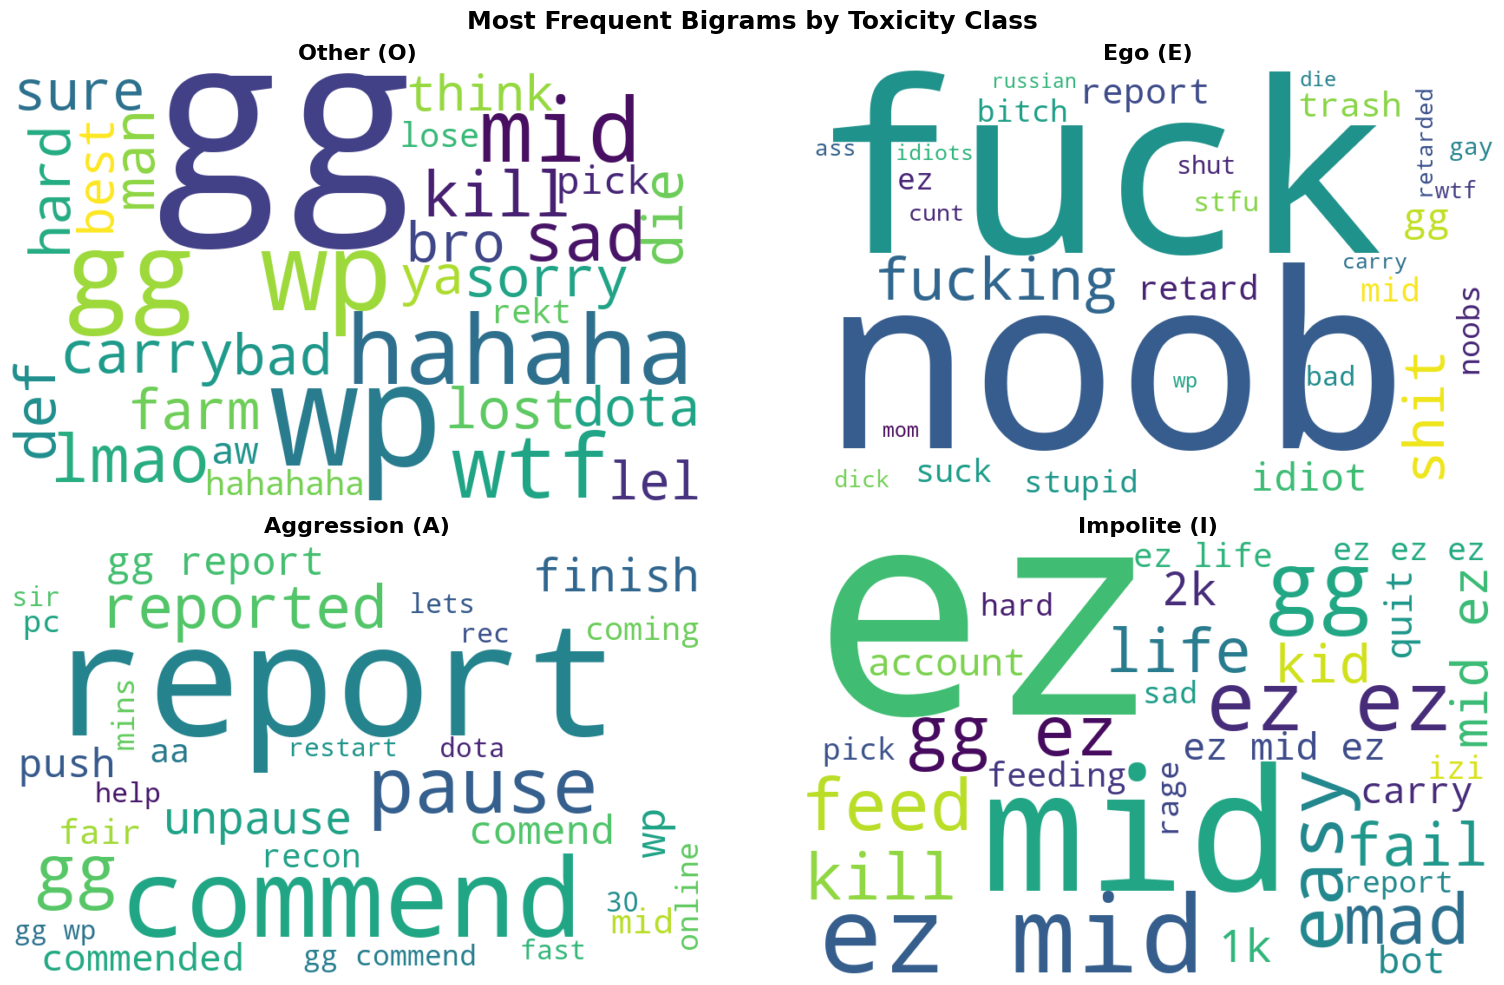

In [37]:
class_map_dota = {0: "Other (O)", 1: "Ego (E)", 2: "Aggression (A)", 3: "Impolite (I)"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(sorted(dota_train_df["label"].unique())):
    class_text = dota_train_df.loc[dota_train_df["label"] == cls, "message"].astype(str)

    bigram_vectorizer = CountVectorizer(
        strip_accents="unicode",
        lowercase=True,
        stop_words=list(STOPWORDS),
        max_df=0.90,
        ngram_range=(1, 3)
    )

    bigrams_train = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_train.sum(axis=0).A1
    bigram_names  = bigram_vectorizer.get_feature_names_out()

    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count":  bigram_counts
    }).sort_values(by="count", ascending=False).head(30)

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], bigram_freq_train["count"]))
        wordcloud = WordCloud(width=800, height=500, background_color="white").generate_from_frequencies(bigram_dict)
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)

plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Other (non-toxic) uses coordination language (gg, wp, nice). Ego centers on boasting and blame directed at teammates. Aggression uses direct insults and profanity. Impolite uses mild rudeness without explicit slurs - the most ambiguous class and hardest to distinguish from Ego.

- **Signals:**
    - Other (O): gg, wp, kill, carry, hard, bad, wtf - neutral game outcomes + sportsmanship

    - Ego (E): noob, fuck, fucking, shit, idiot, retard - skill attacks

    - Aggression (A): report, reported, reporting - behavior complaints dominate clearly

    - Impolite (I): ez, mid, easy, bot, life, kid, rage - condescension

### Pre-processing

Same TweetTokenizer pipeline as WoT - Dota 2 chat is structurally identical: short, informal, abbreviation-heavy. All-caps words (`REPORT`, `GG`) preserved for expressive intensity.

In [38]:
# apply same cleaner used for WoT
dota_train_df["clean_tokens"] = dota_train_df["message"].apply(tokenize)
dota_val_df["clean_tokens"] = dota_val_df["message"].apply(tokenize)

print("Sample cleaned messages:")
dota_train_df["clean_tokens"]

Sample cleaned messages:


0                     [dick]
1                         []
2              [pause, ibrb]
3                 [recorder]
4                         []
                ...         
32226                    [g]
32227    [escape, ceasepool]
32228                     []
32229               [gg, wp]
32230                   [ez]
Name: clean_tokens, Length: 32231, dtype: object

#### Save Splits

In [39]:
# save splits to parquet
dota_train_df.to_parquet(DATA_DIR_DOTA / "dota_train_ml.parquet", index=False)
dota_val_df.to_parquet(DATA_DIR_DOTA / "dota_val_ml.parquet", index=False)

print("Saved:")
print(f"dota_train_ml.parquet — {dota_train_df.shape}")
print(f"dota_val_ml.parquet  — {dota_val_df.shape}")

Saved:
dota_train_ml.parquet — (32231, 4)
dota_val_ml.parquet  — (3582, 3)
